COMPARISON OF 3 CLUSTERING ALGORITHMS

 STEP 1: Loading Data
----------------------------------------
 Data loaded successfully!
   Shape: (1025, 13)
   Samples: 1025

1. K-MEANS CLUSTERING
 Time taken: 0.080 seconds
 Silhouette Score: 0.125
 Adjusted Rand Index: 0.259

2. HIERARCHICAL CLUSTERING
 Time taken: 0.058 seconds
 Silhouette Score: 0.153
 Adjusted Rand Index: 0.243

3. DBSCAN CLUSTERING
 Time taken: 0.170 seconds
 Number of clusters: 1
 Noise points: 47 (4.6%)
 Silhouette Score: Not enough clusters
 Adjusted Rand Index: 0.006

FINAL COMPARISON TABLE

               Time (sec)  Silhouette Score  Adjusted Rand Index  Clusters  \
K-Means           0.0800            0.1247               0.2590       3.0   
Hierarchical      0.0585            0.1533               0.2427       3.0   
DBSCAN            0.1700           -1.0000               0.0061       1.0   

              Noise  
K-Means         0.0  
Hierarchical    0.0  
DBSCAN         47.0  

 BEST ALGORITHM BY METRIC
 Fastest

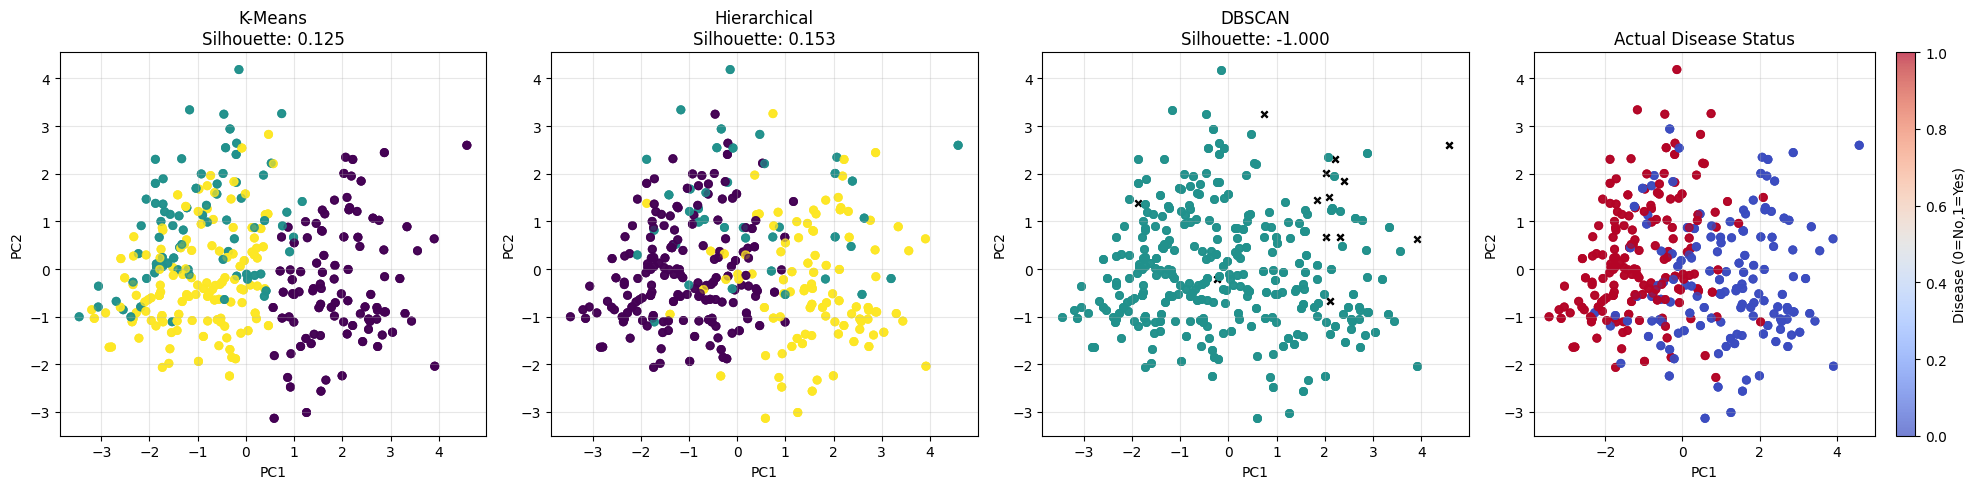


 STEP 3: Bar Chart Comparison
----------------------------------------


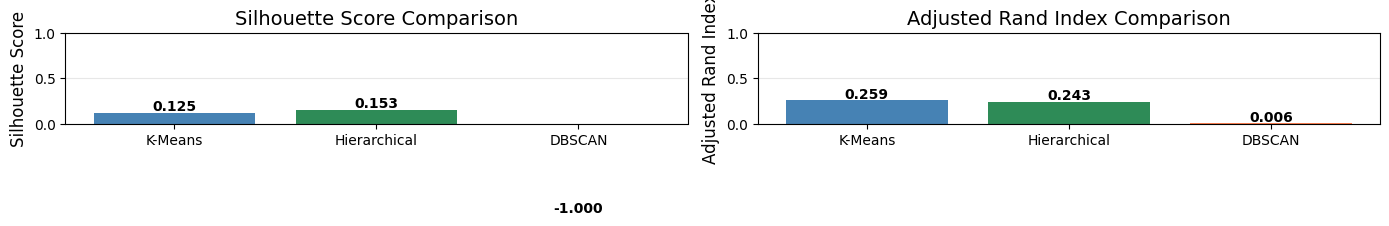


 FINAL SUMMARY

 Algorithm Characteristics:

┌─────────────────┬────────────────┬────────────────┬────────────────┐
│    Algorithm    │    Best For    │   Advantages   │   Disadvantages│
├─────────────────┼────────────────┼────────────────┼────────────────┤
│    K-Means      │ Spherical      │ Fast, Scalable │ Assumes round  │
│                 │ clusters       │ Easy to use    │ clusters       │
├─────────────────┼────────────────┼────────────────┼────────────────┤
│  Hierarchical   │ Small datasets │ No K needed    │ Slow for large │
│                 │ (Dendrogram)   │ Visual tree    │ data           │
├─────────────────┼────────────────┼────────────────┼────────────────┤
│    DBSCAN       │ Irregular      │ Finds noise    │ Needs parameter│
│                 │ shapes         │ Any shape      │ tuning         │
└─────────────────┴────────────────┴────────────────┴────────────────┘


 CLUSTERING COMPARISON COMPLETE!

 Results saved to 'clustering_comparison_results.csv'


In [2]:
"""
COMPARISON OF ALL 3 CLUSTERING ALGORITHMS
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("COMPARISON OF 3 CLUSTERING ALGORITHMS")
print("="*60)

# ============================================
# STEP 1: Load Data
# ============================================
print("\n STEP 1: Loading Data")
print("-"*40)

X_scaled = pd.read_csv('X_scaled.csv')
df_original = pd.read_csv('heart.csv')
y_true = df_original['target']

print(f" Data loaded successfully!")
print(f"   Shape: {X_scaled.shape}")
print(f"   Samples: {len(X_scaled)}")

results = {}

# ============================================
# 1. K-MEANS CLUSTERING
# ============================================
print("\n" + "="*60)
print("1. K-MEANS CLUSTERING")
print("="*60)

start_time = time.time()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)
time_kmeans = time.time() - start_time

sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
ari_kmeans = adjusted_rand_score(y_true, clusters_kmeans)

results['K-Means'] = {
    'Time (sec)': time_kmeans,
    'Silhouette Score': sil_kmeans,
    'Adjusted Rand Index': ari_kmeans,
    'Clusters': len(set(clusters_kmeans)),
    'Noise': 0
}

print(f" Time taken: {time_kmeans:.3f} seconds")
print(f" Silhouette Score: {sil_kmeans:.3f}")
print(f" Adjusted Rand Index: {ari_kmeans:.3f}")

# ============================================
# 2. HIERARCHICAL CLUSTERING
# ============================================
print("\n" + "="*60)
print("2. HIERARCHICAL CLUSTERING")
print("="*60)

start_time = time.time()
linked = linkage(X_scaled, method='ward')
clusters_hc = fcluster(linked, 3, criterion='maxclust')
time_hc = time.time() - start_time

sil_hc = silhouette_score(X_scaled, clusters_hc)
ari_hc = adjusted_rand_score(y_true, clusters_hc)

results['Hierarchical'] = {
    'Time (sec)': time_hc,
    'Silhouette Score': sil_hc,
    'Adjusted Rand Index': ari_hc,
    'Clusters': len(set(clusters_hc)),
    'Noise': 0
}

print(f" Time taken: {time_hc:.3f} seconds")
print(f" Silhouette Score: {sil_hc:.3f}")
print(f" Adjusted Rand Index: {ari_hc:.3f}")

# ============================================
# 3. DBSCAN CLUSTERING
# ============================================
print("\n" + "="*60)
print("3. DBSCAN CLUSTERING")
print("="*60)

start_time = time.time()
dbscan = DBSCAN(eps=3.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)
time_dbscan = time.time() - start_time

# For DBSCAN, exclude noise points from silhouette
if len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0) > 1:
    mask = clusters_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask], clusters_dbscan[mask])
else:
    sil_dbscan = -1

ari_dbscan = adjusted_rand_score(y_true, clusters_dbscan)
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

results['DBSCAN'] = {
    'Time (sec)': time_dbscan,
    'Silhouette Score': sil_dbscan,
    'Adjusted Rand Index': ari_dbscan,
    'Clusters': n_clusters_dbscan,
    'Noise': n_noise
}

print(f" Time taken: {time_dbscan:.3f} seconds")
print(f" Number of clusters: {n_clusters_dbscan}")
print(f" Noise points: {n_noise} ({n_noise/len(X_scaled)*100:.1f}%)")
if sil_dbscan != -1:
    print(f" Silhouette Score: {sil_dbscan:.3f}")
else:
    print(f" Silhouette Score: Not enough clusters")
print(f" Adjusted Rand Index: {ari_dbscan:.3f}")

# ============================================
# COMPARISON TABLE
# ============================================
print("\n" + "="*60)
print("FINAL COMPARISON TABLE")
print("="*60)

comparison_df = pd.DataFrame(results).T
print("\n", comparison_df.round(4))

# Best by each metric
print("\n" + "="*60)
print(" BEST ALGORITHM BY METRIC")
print("="*60)

best_time = comparison_df['Time (sec)'].idxmin()
best_sil = comparison_df['Silhouette Score'].idxmax()
best_ari = comparison_df['Adjusted Rand Index'].idxmax()

print(f" Fastest: {best_time} ({comparison_df.loc[best_time, 'Time (sec)']:.3f} sec)")
print(f" Best Silhouette: {best_sil} ({comparison_df.loc[best_sil, 'Silhouette Score']:.3f})")
print(f" Best ARI: {best_ari} ({comparison_df.loc[best_ari, 'Adjusted Rand Index']:.3f})")

# ============================================
# VISUAL COMPARISON
# ============================================
print("\n STEP 2: Visual Comparison of All 3 Methods")
print("-"*40)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', s=30, alpha=0.7)
axes[0].set_title(f'K-Means\nSilhouette: {sil_kmeans:.3f}', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# Hierarchical
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc, cmap='viridis', s=30, alpha=0.7)
axes[1].set_title(f'Hierarchical\nSilhouette: {sil_hc:.3f}', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

# DBSCAN
unique_labels = sorted(set(clusters_dbscan))
colors = plt.cm.viridis(np.linspace(0, 1, max(3, len(unique_labels))))
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'black'
        marker = 'x'
        s = 20
    else:
        marker = 'o'
        s = 30
    mask = clusters_dbscan == label
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, s=s, alpha=0.7)
axes[2].set_title(f'DBSCAN\nSilhouette: {sil_dbscan:.3f}', fontsize=12)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)

# Actual Disease Status
scatter = axes[3].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=30, alpha=0.7)
axes[3].set_title('Actual Disease Status', fontsize=12)
axes[3].set_xlabel('PC1')
axes[3].set_ylabel('PC2')
axes[3].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[3], label='Disease (0=No,1=Yes)')

plt.tight_layout()
plt.savefig('all_clustering_comparison.png', dpi=150)
plt.show()

# ============================================
# BAR CHART COMPARISON
# ============================================
print("\n STEP 3: Bar Chart Comparison")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Silhouette Scores
metrics = comparison_df.index
sil_scores = comparison_df['Silhouette Score'].values

axes[0].bar(metrics, sil_scores, color=['steelblue', 'seagreen', 'coral'])
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score Comparison', fontsize=14)
axes[0].set_ylim(0, 1)
for i, v in enumerate(sil_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Adjusted Rand Index
ari_scores = comparison_df['Adjusted Rand Index'].values

axes[1].bar(metrics, ari_scores, color=['steelblue', 'seagreen', 'coral'])
axes[1].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[1].set_title('Adjusted Rand Index Comparison', fontsize=14)
axes[1].set_ylim(0, 1)
for i, v in enumerate(ari_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparison_bar_chart.png', dpi=150)
plt.show()

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print(" FINAL SUMMARY")
print("="*60)

print("""
 Algorithm Characteristics:

┌─────────────────┬────────────────┬────────────────┬────────────────┐
│    Algorithm    │    Best For    │   Advantages   │   Disadvantages│
├─────────────────┼────────────────┼────────────────┼────────────────┤
│    K-Means      │ Spherical      │ Fast, Scalable │ Assumes round  │
│                 │ clusters       │ Easy to use    │ clusters       │
├─────────────────┼────────────────┼────────────────┼────────────────┤
│  Hierarchical   │ Small datasets │ No K needed    │ Slow for large │
│                 │ (Dendrogram)   │ Visual tree    │ data           │
├─────────────────┼────────────────┼────────────────┼────────────────┤
│    DBSCAN       │ Irregular      │ Finds noise    │ Needs parameter│
│                 │ shapes         │ Any shape      │ tuning         │
└─────────────────┴────────────────┴────────────────┴────────────────┘
""")

print("\n" + "="*60)
print(" CLUSTERING COMPARISON COMPLETE!")
print("="*60)

# Save results to CSV
comparison_df.to_csv('clustering_comparison_results.csv')
print("\n Results saved to 'clustering_comparison_results.csv'")